In [3]:
pip install pyarrow --trusted-host pypi.org --trusted-host files.pythonhosted.org

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.6 MB/s  0:00:02m0:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install lightgbm --trusted-host pypi.org --trusted-host files.pythonhosted.org

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 18.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
# Load the parquet file 
df = pd.read_parquet('listings_features.parquet') 

# Separate target from features
y = df['log_price']

# For first baseline model, let's select just a few clean numeric features
feature_cols = ['accommodates', 'bedrooms', 'beds', 'bathrooms_parsed', 
    'dist_city_center', 'dist_kreuzberg', 'amenities_count',
    'review_sentiment_mean', 'description_sentiment']
X = df[feature_cols]

# Split data into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the remaining 80% into TRAIN (60% total) and VALIDATION (20% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)
print(f"Training set rows:   {X_train.shape[0]}")
print(f"Validation set rows: {X_val.shape[0]}")
print(f"Test set rows: {X_test.shape[0]}")

Training set rows:   4188
Validation set rows: 1396
Test set rows: 1397


In [3]:
#Train Linear Regression Model as baseline

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

#Predict on Val dataset
y_val_pred = baseline_model.predict(X_val)
print(f"\nValidation R² Score: {r2_score(y_val, y_val_pred):.4f}")


Validation R² Score: 0.2749


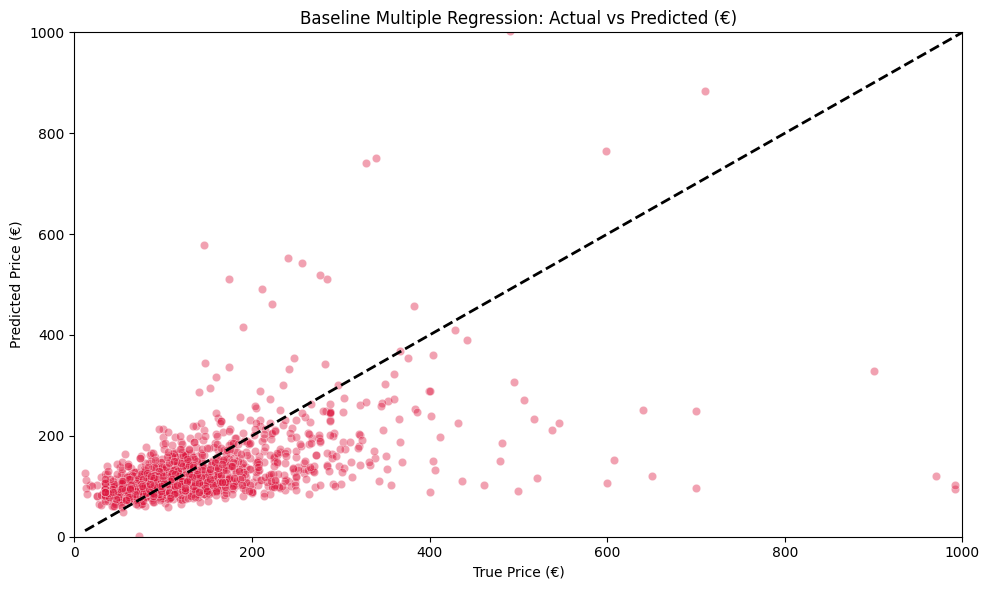

In [11]:
#Plot - Actual vs Predicted

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a figure with a single plot layout
fig, ax = plt.subplots(figsize=(10, 6))

y_val_real = np.expm1(y_val)
y_baseline_pred_real = np.expm1(baseline_model.predict(X_val[feature_cols]))

sns.scatterplot(x=y_val_real, y=y_baseline_pred_real, alpha=0.4, color='crimson', ax=ax)
ax.plot([y_val_real.min(), y_val_real.max()], [y_val_real.min(), y_val_real.max()], 'k--', lw=2)

ax.set_xlim([0, 1000])
ax.set_ylim([0, 1000])

ax.set_title("Baseline Multiple Regression: Actual vs Predicted (€)")
ax.set_xlabel("True Price (€)")
ax.set_ylabel("Predicted Price (€)")

plt.tight_layout()
plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor

# This includes all neighborhood numerical values, text embeddings, and spatial metrics and drops rest
X_all = df.drop(columns=['id', 'description', 'host_name', 'price', 'log_price'], errors='ignore')

X_num = X_all.select_dtypes(include=[np.number])

# Re-split into datasets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print(f"Training Random Forest with {X_train.shape[1]} multimodal features")

# 3. Initialize and train a Random Forest Regressor
# We set n_estimators=100 (100 trees) and random_state for consistency
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 4. Check performance on the val Set
y_val_pred_rf = rf_model.predict(X_val)
print(f"Random Forest Validation R² Score: {r2_score(y_val, y_val_pred_rf):.4f}")

Training Random Forest with 117 multimodal features
Random Forest Validation R² Score: 0.7740


In [16]:
# Evaluate on the Training set (what the model already saw)
y_train_pred_rf = rf_model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred_rf)

# Evaluate on the Validation set (completely unseen to the model)
val_r2 = r2_score(y_val, y_val_pred_rf)


print(f"Training R² Score:   {train_r2:.4f}")
print(f"Validation R² Score: {val_r2:.4f}")
print(f"Gap (Train - Val):   {train_r2 - val_r2:.4f}")

Training R² Score:   0.9707
Validation R² Score: 0.7740
Gap (Train - Val):   0.1967


/local/jobs/u28600_14356751/ipykernel_4006768/1952355285.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.values, y=rf_importances.index, ax=axes[0], palette="viridis")


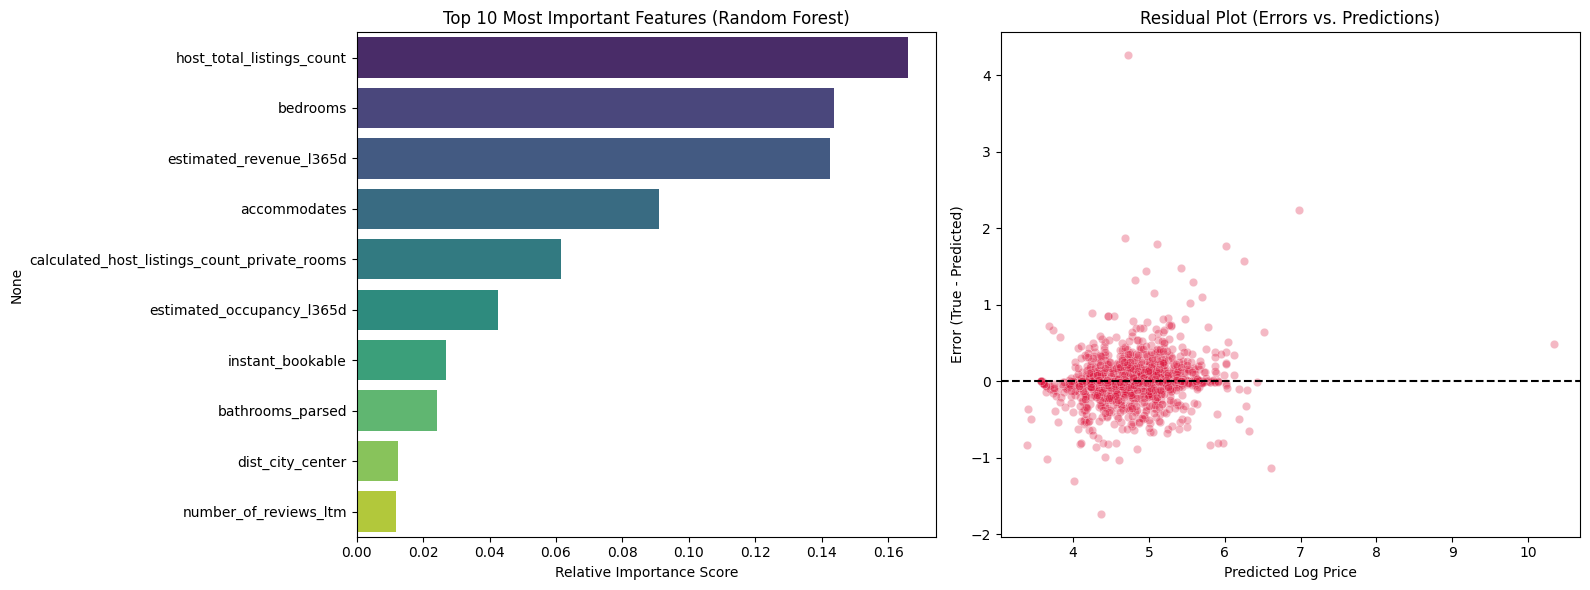

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature Importance 
# extract the top 10 most influential columns out of our numerical dataset
importances = rf_model.feature_importances_
feature_names = X_train.columns
rf_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

sns.barplot(x=rf_importances.values, y=rf_importances.index, ax=axes[0], palette="viridis")
axes[0].set_title("Top 10 Most Important Features (Random Forest)")
axes[0].set_xlabel("Relative Importance Score")

# Residual Plot 
# We compare True Log Prices vs Predicted Log Prices
residuals = y_val - y_val_pred_rf
sns.scatterplot(x=y_val_pred_rf, y=residuals, alpha=0.3, ax=axes[1], color="crimson")
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title("Residual Plot (Errors vs. Predictions)")
axes[1].set_xlabel("Predicted Log Price")
axes[1].set_ylabel("Error (True - Predicted)")

plt.tight_layout()
plt.show()

In [18]:
X_all = df.drop(columns=['id', 'description', 'host_name', 'price', 'log_price','estimated_revenue_365d', 
    'estimated_occupancy_365d', 
    'host_total_listings_count', 
    'calculated_host_listings_count_private_rooms'], errors='ignore') #we remove columns that potentially cause data leakage

X_num = X_all.select_dtypes(include=[np.number])

# Re-split into datasets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print(f"Training Random Forest with {X_train.shape[1]} multimodal features")

# 3. Initialize and train a Random Forest Regressor
# We set n_estimators=100 (100 trees) and random_state for consistency
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 4. Check performance on the val Set
y_val_pred_rf = rf_model.predict(X_val)
print(f"Random Forest Validation R² Score: {r2_score(y_val, y_val_pred_rf):.4f}")

Training Random Forest with 115 multimodal features
Random Forest Validation R² Score: 0.8014


In [6]:
# Check for columns that are NOT numerical
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Number of non-numerical columns found: {len(non_numeric_cols)}")
print("Here are the non-numerical columns:")
print(non_numeric_cols)

Number of non-numerical columns found: 144
Here are the non-numerical columns:
['description', 'host_name', 'property_type', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_cleansed_Albrechtstr.', 'neighbourhood_cleansed_Alexanderplatz', 'neighbourhood_cleansed_Allende-Viertel', 'neighbourhood_cleansed_Alt  Treptow', 'neighbourhood_cleansed_Alt-Hohenschönhausen Nord', 'neighbourhood_cleansed_Alt-Hohenschönhausen Süd', 'neighbourhood_cleansed_Alt-Lichtenberg', 'neighbourhood_cleansed_Altglienicke', 'neighbourhood_cleansed_Altstadt-Kietz', 'neighbourhood_cleansed_Barstraße', 'neighbourhood_cleansed_Baumschulenweg', 'neighbourhood_cleansed_Biesdorf', 'neighbourhood_cleansed_Blankenburg/Heinersdorf/Märchenland', 'neighbourhood_cleansed_Blankenfelde/Niederschönhausen', 'neighbourhood_cleansed_Bohnsdorf', 'neighbourhood_cleansed_Britz', 'neighbourhood_cleansed_Brunnenstr. Nord', 'neighbourhood_cleansed_Brunnenstr. Süd', 'neighbourhood_cleansed_Brunsb

In [19]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error

# 1. LightGBM can handle column names with special characters, 
# but it prefers standard alphanumeric characters. Let's fix column names just in case.
import re
X_train_lgb = X_train.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
X_val_lgb = X_val.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '', x))

# 2. Initialize the LightGBM Regressor
# We'll use 500 estimators with a small learning rate to build highly precise trees
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

# 3. Train the model using early stopping to prevent overfitting
# The model will look at the Validation set and stop if it stops improving for 20 rounds
lgb_model.fit(
    X_train_lgb, y_train,
    eval_set=[(X_val_lgb, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# 4. Predict and evaluate on the Validation set
y_val_pred_lgb = lgb_model.predict(X_val_lgb)
print(f"LightGBM Validation R² Score: {r2_score(y_val, y_val_pred_lgb):.4f}")
print(f"LightGBM Validation MAE (Log scale): {mean_absolute_error(y_val, y_val_pred_lgb):.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001614 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18327
[LightGBM] [Info] Number of data points in the train set: 4188, number of used features: 115
[LightGBM] [Info] Start training from score 4.797319
LightGBM Validation R² Score: 0.8650
LightGBM Validation MAE (Log scale): 0.1226


In [20]:
# 1. Predict on the Training data using LightGBM
y_train_pred_lgb = lgb_model.predict(X_train_lgb)
lgb_train_r2 = r2_score(y_train, y_train_pred_lgb)

# 2. Grab your validation score from the previous output
lgb_val_r2 = r2_score(y_val, y_val_pred_lgb)

print("=== LIGHTGBM OVERFITTING CHECK ===")
print(f"LightGBM Training R² Score:   {lgb_train_r2:.4f}")
print(f"LightGBM Validation R² Score: {lgb_val_r2:.4f}")
print(f"New Overfitting Gap:          {lgb_train_r2 - lgb_val_r2:.4f}")

=== LIGHTGBM OVERFITTING CHECK ===
LightGBM Training R² Score:   0.9964
LightGBM Validation R² Score: 0.8650
New Overfitting Gap:          0.1314


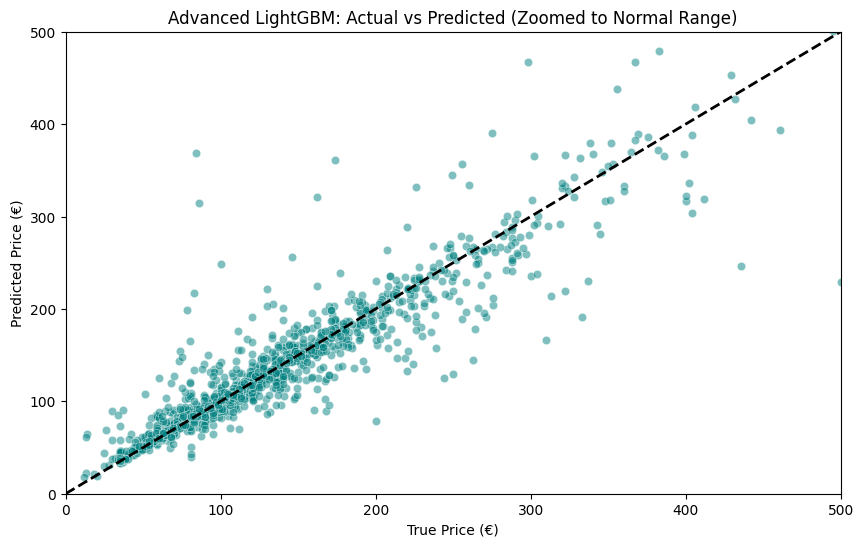

In [21]:
# Create a clean single-plot window for LightGBM
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Transform LightGBM log predictions back to raw Euros
y_val_real = np.expm1(y_val)
y_lgb_pred_real = np.expm1(lgb_model.predict(X_val_lgb))

# 2. Plot the scatter points in teal
sns.scatterplot(x=y_val_real, y=y_lgb_pred_real, alpha=0.5, color='teal', ax=ax)

# 3. Draw a clean perfect diagonal line capped exactly at €500
ax.plot([0, 500], [0, 500], 'k--', lw=2)

# 4. FIX THE LOOK: Enforce the exact same zoomed boundaries
ax.set_xlim([0, 500])
ax.set_ylim([0, 500])

# 5. Labels and Titles
ax.set_title("Advanced LightGBM: Actual vs Predicted (Zo")
ax.set_xlabel("True Price (€)")
ax.set_ylabel("Predicted Price (€)")

plt.show()

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Load data
df = pd.read_parquet('listings_features.parquet')
y = df['log_price']

# 2. Drop the 3 strict raw text identifier columns
X_all = df.drop(columns=['id', 'description', 'host_name', 'property_type', 'price', 'log_price'], errors='ignore')

# 3. CONVERSION STEP: Convert true booleans/objects containing 1s/0s into real floats
for col in X_all.columns:
    # If the column is boolean or stored as a string format of numbers, cast it to float
    if X_all[col].dtype == 'bool' or X_all[col].dtype.name == 'boolean':
        X_all[col] = X_all[col].astype(float)
    elif X_all[col].dtype == 'object':
        # Safely attempt to convert any leftover categorical dummies to float
        X_all[col] = pd.to_numeric(X_all[col], errors='coerce')

# Fill any NaN gaps created by conversion with 0
X_all = X_all.fillna(0)

print(f"Total features successfully unlocked for training: {X_all.shape[1]}")

# 4. Re-split with everything converted to numeric
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

# 5. Re-run Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_val_pred_rf = rf_model.predict(X_val)
print(f"\nFully Unlocked Random Forest Validation R² Score: {r2_score(y_val, y_val_pred_rf):.4f}")

Total features successfully unlocked for training: 258

Fully Unlocked Random Forest Validation R² Score: 0.7767


In [10]:
# 1. Predict on the training data (what the model memorized)
y_train_pred_rf = rf_model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred_rf)

# 2. Predict on the validation data (completely unseen)
val_r2 = r2_score(y_val, y_val_pred_rf)

print("=== RE-EVALUATION WITH ALL FEATURES CONVERTED ===")
print(f"Training R² Score:   {train_r2:.4f}")
print(f"Validation R² Score: {val_r2:.4f}")
print(f"Overfitting Gap:     {train_r2 - val_r2:.4f}")

=== RE-EVALUATION WITH ALL FEATURES CONVERTED ===
Training R² Score:   0.9718
Validation R² Score: 0.7767
Overfitting Gap:     0.1950


In [14]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import re
from sklearn.metrics import r2_score

# 1. Load data
df = pd.read_parquet('listings_features.parquet')
y = df['log_price']

# 2. Drop strict text identifiers
X_all = df.drop(columns=['id', 'description', 'host_name', 'property_type', 'price', 'log_price'], errors='ignore')

# Force numeric conversions
for col in X_all.columns:
    if X_all[col].dtype == 'bool' or X_all[col].dtype.name == 'boolean':
        X_all[col] = X_all[col].astype(float)
    elif X_all[col].dtype == 'object':
        X_all[col] = pd.to_numeric(X_all[col], errors='coerce')
X_all = X_all.fillna(0)

# 3. FIX: Isolate the 50 description embedding columns
emb_cols = [col for col in X_all.columns if col.startswith('desc_emb_')]
X_emb = X_all[emb_cols]

# 4. Apply PCA to compress 50 embeddings down to 5 components
pca = PCA(n_components=5, random_state=42)
X_emb_pca = pca.fit_transform(X_emb)

# Convert PCA result to a clean DataFrame
pca_cols = [f'text_pca_{i}' for i in range(5)]
df_pca = pd.DataFrame(X_emb_pca, columns=pca_cols, index=X_all.index)

# 5. Drop the original 50 embeddings and glue the 5 clean PCA components in
X_compressed = X_all.drop(columns=emb_cols)
X_compressed = pd.concat([X_compressed, df_pca], axis=1)

print(f"Old feature count: {X_all.shape[1]}")
print(f"New compressed feature count: {X_compressed.shape[1]}")

# 6. Re-split with our new compressed dataset
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_compressed, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

# Clean column names for LightGBM
X_train_lgb = X_train.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
X_val_lgb = X_val.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '', x))

# 7. Retrain LightGBM
lgb_model_pca = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, n_jobs=-1)
lgb_model_pca.fit(
    X_train_lgb, y_train,
    eval_set=[(X_val_lgb, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# 8. Check your new Train and Validation scores
train_score = r2_score(y_train, lgb_model_pca.predict(X_train_lgb))
val_score = r2_score(y_val, lgb_model_pca.predict(X_val_lgb))

print("\n=== RESULTS AFTER TEXT EMBEDDING COMPRESSION (PCA) ===")
print(f"Training R² Score:   {train_score:.4f}")
print(f"Validation R² Score: {val_score:.4f}")
print(f"Overfitting Gap:     {train_score - val_score:.4f}")

Old feature count: 258
New compressed feature count: 213
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001362 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7043
[LightGBM] [Info] Number of data points in the train set: 4188, number of used features: 130
[LightGBM] [Info] Start training from score 4.797319

=== RESULTS AFTER TEXT EMBEDDING COMPRESSION (PCA) ===
Training R² Score:   0.9879
Validation R² Score: 0.8647
Overfitting Gap:     0.1232


In [15]:
# 1. Predict on the Validation set using our PCA-backed LightGBM model
y_val_pred_log = lgb_model_pca.predict(X_val_lgb)

# 2. Convert log values back to raw Euros
y_val_real = np.expm1(y_val)
y_val_pred_real = np.expm1(y_val_pred_log)

# 3. Calculate Mean Absolute Error in Euros
from sklearn.metrics import mean_absolute_error
mae_euros = mean_absolute_error(y_val_real, y_val_pred_real)

print("=== REAL WORLD PERFORMANCE ===")
print(f"Validation R² Score: {r2_score(y_val, y_val_pred_log):.4f}")
print(f"Average Price Error: €{mae_euros:.2f} per night")

=== REAL WORLD PERFORMANCE ===
Validation R² Score: 0.8647
Average Price Error: €53.09 per night
